In [32]:
pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

In [34]:
hrdf=pd.read_csv('HR_Data_MNC_Data Science Lovers.csv')

# EDA starts from here

In [35]:
hrdf.head(3)

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084


In [36]:
hrdf.drop(columns='Unnamed: 0', inplace=True)

In [37]:
hrdf.columns

Index(['Employee_ID', 'Full_Name', 'Department', 'Job_Title', 'Hire_Date',
       'Location', 'Performance_Rating', 'Experience_Years', 'Status',
       'Work_Mode', 'Salary_INR'],
      dtype='str')

In [38]:
hrdf.shape

(2000000, 11)

In [39]:
hrdf.dtypes

Employee_ID             str
Full_Name               str
Department              str
Job_Title               str
Hire_Date               str
Location                str
Performance_Rating    int64
Experience_Years      int64
Status                  str
Work_Mode               str
Salary_INR            int64
dtype: object

In [40]:
hrdf['Hire_Date']=pd.to_datetime(hrdf['Hire_Date'])

In [41]:
hrdf.dtypes

Employee_ID                      str
Full_Name                        str
Department                       str
Job_Title                        str
Hire_Date             datetime64[us]
Location                         str
Performance_Rating             int64
Experience_Years               int64
Status                           str
Work_Mode                        str
Salary_INR                     int64
dtype: object

In [42]:
hrdf['Year']=hrdf['Hire_Date'].dt.year

hrdf.Year

In [43]:
hrdf.isnull().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
Year                  0
dtype: int64

# EDA completed. Now move the data to SQL server for the analysis  To match the details that I see here.

In [94]:
pip install pyodbc

Note: you may need to restart the kernel to use updated packages.


In [119]:
from urllib.parse import quote_plus 
conn_str = (
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-3A3OQA1\\SQLEXPRESS;"
    "Database=SUCHARITA;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
    "TrustServerCertificate=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={quote_plus(conn_str)}")
hrdf.to_sql("HRData", con=engine, if_exists="replace", index=False)


58

In [106]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [122]:
HRDataDF=pd.read_sql("select * from HRData", con=engine)
HRDataDF.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year,Country
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011,Denmark
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018,Costa Rica


# Q1 Disrtibution of employee status

In [44]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [45]:
hrdf.to_csv("HRData.csv", index=False)

In [46]:
x=[0,1,2,3]
for i in x:  
    if len(hrdf['Full_Name'].loc[i]) > 100:
        print(hrdf['Full_Name'].loc[i])
        print(len(hrdf['Full_Name'].loc[i]))

In [47]:
hrdf.isnull().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
Year                  0
dtype: int64

In [48]:
    hrdf.groupby('Status').Employee_ID.value_counts()

Status      Employee_ID
Active      EMP2000000     1
            EMP0983740     1
            EMP0983739     1
            EMP0983738     1
            EMP0983737     1
                          ..
Terminated  EMP0917649     1
            EMP1694632     1
            EMP1694647     1
            EMP0290828     1
            EMP1667028     1
Name: count, Length: 2000000, dtype: int64

In [49]:
status_count=hrdf.groupby('Status')['Employee_ID'].count()

In [50]:
status_count

Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: Employee_ID, dtype: int64

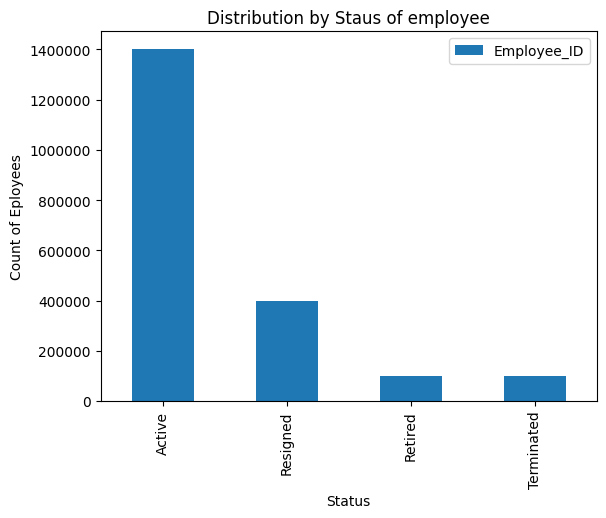

In [51]:
status_count.plot(kind='bar')
plt.title("Distribution by Staus of employee", loc= 'center')
plt.xlabel('Status')
plt.ylabel('Count of Eployees')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()


# Empl;oyee count in each department

In [52]:
hrdf.head(1)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011


In [53]:
employee_byDEPT=hrdf.groupby('Department')['Employee_ID'].count().sort_values(ascending=False)

In [54]:
employee_byDEPT

Department
IT            601042
Sales         400031
Operations    300095
Marketing     240081
Finance       199873
HR            159119
R&D            99759
Name: Employee_ID, dtype: int64

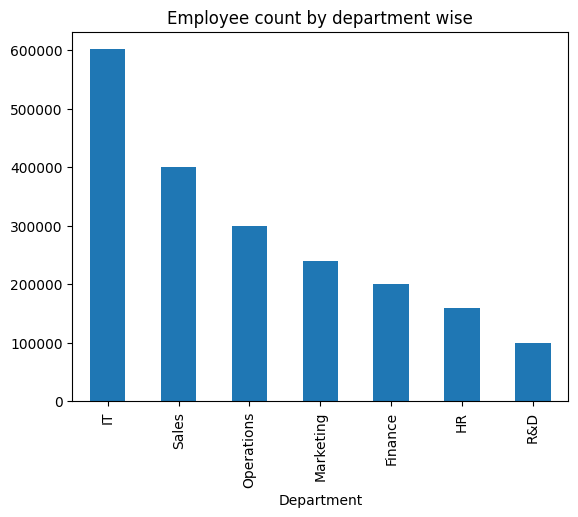

In [55]:
employee_byDEPT.plot(kind='bar')
plt.title("Employee count by department wise")
plt.show()

In [56]:
#there are more employees in IT department and R&D has lowest number of employees.

# Q3 average salary by department wise

In [57]:
avg_sal_deptwsie=hrdf.groupby('Department')['Salary_INR'].mean().sort_values(ascending=False)

In [58]:
avg_sal_deptwsie

Department
IT            1.129858e+06
Finance       9.404117e+05
R&D           8.003772e+05
Sales         7.929579e+05
Marketing     7.699362e+05
Operations    7.546263e+05
HR            7.438536e+05
Name: Salary_INR, dtype: float64

# Q4: Workmode distribution

In [59]:
workmode_emp=hrdf.groupby('Work_Mode')['Employee_ID'].count().sort_values(ascending=False)

In [60]:
workmode_emp

Work_Mode
On-site    1199109
Remote      800891
Name: Employee_ID, dtype: int64

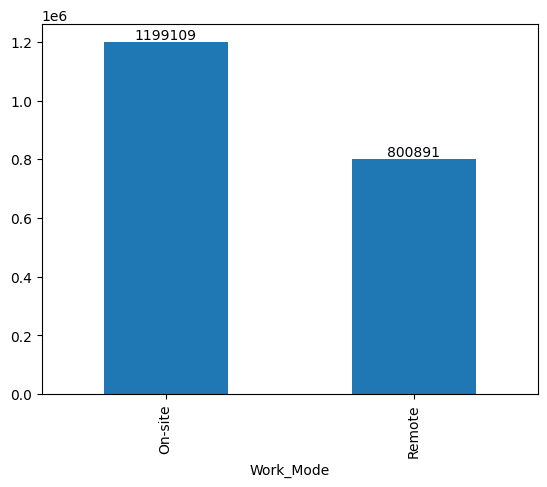

In [61]:
ax=workmode_emp.plot(kind='bar')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,   # X position (center of bar)
        p.get_height(),                  # Y position (top of bar)
        str(p.get_height()),             # Text (bar height)
        ha='center', va='bottom'         # Align center horizontally, bottom vertically
    )

plt.show()

In [62]:
# looks like there are more people in onsite than remote

# Q5 which job has highest average salary

In [63]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [64]:
hrdf.groupby('Job_Title')['Salary_INR'].mean().sort_values(ascending=False)

Job_Title
IT Manager                       2.098156e+06
Finance Manager                  1.743242e+06
HR Manager                       1.252402e+06
Business Development Manager     1.252016e+06
Software Engineer                1.199261e+06
Financial Analyst                1.051523e+06
Brand Manager                    8.031278e+05
Innovation Manager               8.018701e+05
Talent Acquisition Specialist    8.014222e+05
CTO                              8.014028e+05
Research Scientist               8.013149e+05
Data Analyst                     8.009964e+05
Content Strategist               8.007600e+05
HR Director                      8.006944e+05
Operations Executive             8.003509e+05
Lab Technician                   8.001815e+05
DevOps Engineer                  7.999492e+05
Account Manager                  7.993737e+05
Sales Director                   7.990694e+05
Marketing Executive              7.987804e+05
Product Developer                7.986523e+05
Operations Director     

In [65]:
#IT manager has highest avarage salary.

# Q6 what is the average salary in differennt departments based on job title.

In [66]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [67]:
hrdf.groupby(['Department','Job_Title'])['Salary_INR'].mean().sort_values(ascending=False)

Department  Job_Title                    
IT          IT Manager                       2.098156e+06
Finance     Finance Manager                  1.743242e+06
HR          HR Manager                       1.252402e+06
Sales       Business Development Manager     1.252016e+06
IT          Software Engineer                1.199261e+06
Finance     Financial Analyst                1.051523e+06
Marketing   Brand Manager                    8.031278e+05
R&D         Innovation Manager               8.018701e+05
HR          Talent Acquisition Specialist    8.014222e+05
IT          CTO                              8.014028e+05
R&D         Research Scientist               8.013149e+05
IT          Data Analyst                     8.009964e+05
Marketing   Content Strategist               8.007600e+05
HR          HR Director                      8.006944e+05
Operations  Operations Executive             8.003509e+05
R&D         Lab Technician                   8.001815e+05
IT          DevOps Engineer   

# Howmany employees are terminated or resigned in each department

In [68]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [69]:
terminated_resigned=hrdf.groupby(['Status','Department'])['Employee_ID'].count()

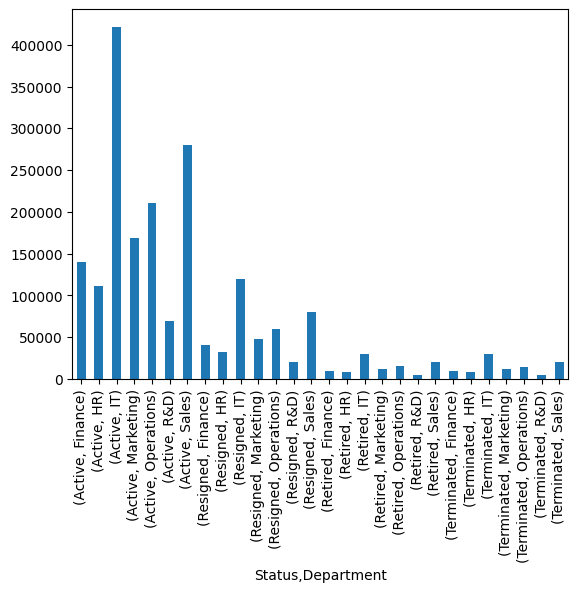

In [70]:
terminated_resigned.plot(kind='bar')
plt.show()

# Q8 how does salary vary with years of exp?

In [71]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [72]:
hrdf[['Job_Title','Salary_INR','Experience_Years']].sort_values(by=['Job_Title','Experience_Years'], ascending=False).head(20)

,Job_Title,Salary_INR,Experience_Years
23898,Talent Acquisition Specialist,540011,15
186479,Talent Acquisition Specialist,551056,15
264919,Talent Acquisition Specialist,843861,15
764214,Talent Acquisition Specialist,464684,15
843654,Talent Acquisition Specialist,834837,15
848412,Talent Acquisition Specialist,596709,15
900867,Talent Acquisition Specialist,834361,15
1141318,Talent Acquisition Specialist,600328,15
1355731,Talent Acquisition Specialist,822874,15
1429324,Talent Acquisition Specialist,416694,15


# Q9 what is the average performance rating by dept

In [73]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [74]:
hrdf.groupby('Department')['Performance_Rating'].mean()

Department
Finance       2.996818
HR            2.995670
IT            2.998216
Marketing     3.004736
Operations    2.996081
R&D           3.001885
Sales         3.006362
Name: Performance_Rating, dtype: float64

# Q10 which country has highest employees

In [75]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018


In [76]:
hrdf['Country']=hrdf['Location'].str.split(",").str[-1].str.strip()

In [77]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year,Country
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011,Denmark
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018,Costa Rica


In [78]:
emp_country=hrdf.groupby('Country')['Employee_ID'].count().sort_values(ascending=False)
emp_country

Country
Congo                     16286
Korea                     16285
Sri Lanka                  8409
Switzerland                8391
British Virgin Islands     8373
                          ...  
Indonesia                  7983
Kazakhstan                 7973
Montenegro                 7972
Bhutan                     7971
Palestinian Territory      7895
Name: Employee_ID, Length: 243, dtype: int64

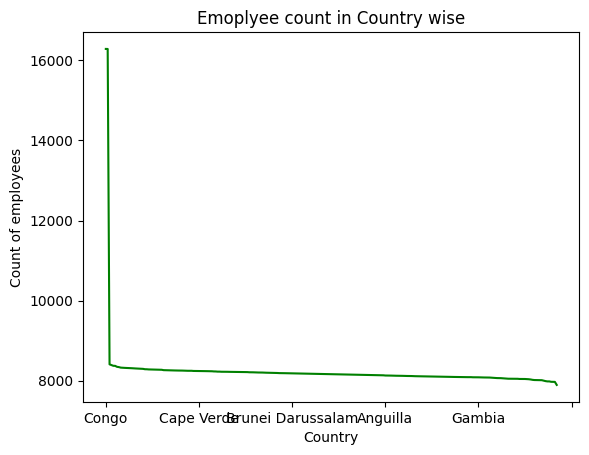

In [79]:
emp_country.plot(kind='line',color='g')
plt.title("Emoplyee count in Country wise")
plt.xlabel("Country")
plt.ylabel("Count of employees")
plt.show()

# Q11 is there a correlation between rating and salary

In [80]:
hrdf['Salary_INR'].corr(hrdf['Performance_Rating'])

np.float64(-0.0002091979994091652)

In [81]:
# the corr values varies between -1 to 1. the above value shows bad relation

# Q12 has the hiring changed over the years?

In [82]:
hrdf.head(1
        )

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year,Country
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011,Denmark


In [83]:
Yearlyhiring=hrdf.groupby('Year')['Employee_ID'].count().sort_values(ascending=False)
Yearlyhiring

Year
2022    201373
2024    200001
2021    199366
2023    198982
2020    175460
2017    160363
2016    160249
2019    160202
2018    159658
2025    122798
2015     85984
2014     40202
2011     40089
2013     39988
2012     39765
2010     15520
Name: Employee_ID, dtype: int64

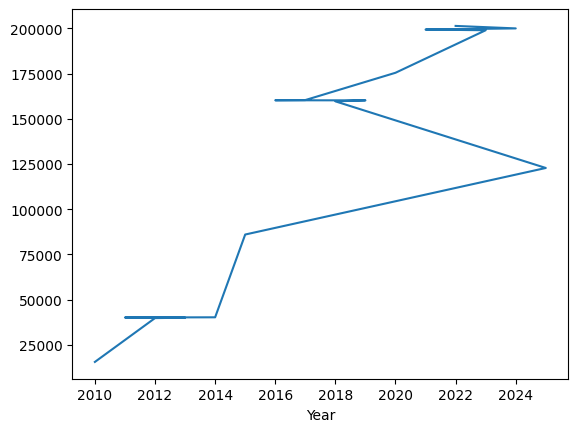

In [84]:
Yearlyhiring.plot(kind='line')
plt.show()

# Q13 Onsite salary vs offshore salary

In [85]:
hrdf.groupby('Work_Mode')['Salary_INR'].sum()

Work_Mode
On-site    1075404054123
Remote      718371457204
Name: Salary_INR, dtype: int64

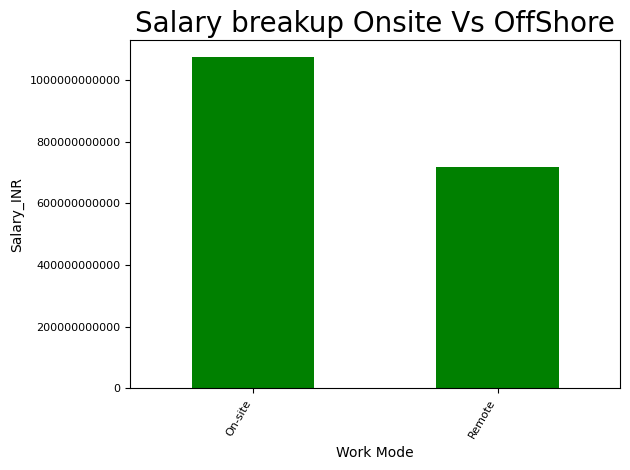

In [86]:
hrdf.groupby('Work_Mode')['Salary_INR'].sum().plot(kind='bar',color='g',fontsize=8)
plt.title("Salary breakup Onsite Vs OffShore",fontsize=20)
plt.xlabel("Work Mode")
plt.ylabel("Salary_INR")
plt.xticks(rotation=60, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# Q14 top 10 employees with highest salary

In [87]:
hrdf.head(1)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year,Country
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011,Denmark


In [88]:
hrdf[['Employee_ID', 'Full_Name','Salary_INR']].sort_values(by='Salary_INR', ascending=False).head(10)

,Employee_ID,Full_Name,Salary_INR
1697605,EMP1697606,Kathryn Owens,2999976
1284141,EMP1284142,Robert Bowman,2999973
1912378,EMP1912379,Christina Delgado,2999944
1904593,EMP1904594,Donald Cohen,2999906
645146,EMP0645147,Brandon Rodriguez,2999889
766571,EMP0766572,Dr. David Mitchell,2999881
1257897,EMP1257898,Cassandra Morales,2999831
1734354,EMP1734355,Debra Rivera,2999811
369339,EMP0369340,Douglas Mann,2999797
1645827,EMP1645828,Jennifer Reynolds,2999751


# Q15. department with highest artition rate

In [89]:
hrdf.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Year,Country
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,2011,Denmark
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,2018,Costa Rica


In [90]:
hrdf[hrdf[ 'Status'] == 'Resigned'].groupby('Department')['Employee_ID'].count().sort_values(ascending=False)

Department
IT            119852
Sales          79725
Operations     59397
Marketing      47793
Finance        40238
HR             31736
R&D            19919
Name: Employee_ID, dtype: int64

In [91]:
hrdf.groupby('Department')['Employee_ID'].agg(col1='count',col2= lambda x: (x=='Resigned').sum())

,col1,col2
Department,,
Finance,199873,0
HR,159119,0
IT,601042,0
Marketing,240081,0
Operations,300095,0
R&D,99759,0
Sales,400031,0
